<a href="https://colab.research.google.com/github/saikiranreddy2437/Deep-Learning/blob/main/code_for_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install Required Libraries
# ==============================
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# 2. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iot scenarios.labeled to iot scenarios.labeled


In [ ]:
# 4. Load Dataset
# ==============================
# Column names derived from a typical Zeek/Bro conn.log file
column_names = [
    'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto',
    'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state',
    'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts',
    'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents',
    'label', 'orig_label', 'resp_label'
]

# We need to skip initial comment lines and the '#fields' and '#types' lines.
# For a typical Zeek/Bro log, these are the first 7 lines (0-6).
# Line 0: #separator
# Line 1: #set_separator
# Line 2: #empty_field
# Line 3: #unset_field
# Line 4: #path
# Line 5: #fields  (This line contains the actual header names, but with '#fields' prefix)
# Line 6: #types   (This line contains type information)
# Line 7: First data row

df = pd.read_csv(
    'iot scenarios.labeled',
    sep='\t',
    header=None,  # No header in the data part, we provide names explicitly
    names=column_names, # Use the predefined column names
    skiprows=7,   # Skip the first 7 lines (0-6) which are metadata
    low_memory=False
)

print("Dataset Loaded")
print(df.head())

Dataset Loaded
                  ts                 uid        id.orig_h id.orig_p  \
0             #types                time           string      addr   
1  1525879831.015811  CUmrqr4svHuSXJy5z7  192.168.100.103     51524   
2  1525879831.025055  CH98aB3s1kJeq6SFOc  192.168.100.103     56305   
3  1525879831.045045   C3GBTkINvXNjVGtN5  192.168.100.103     41101   
4  1525879832.016240   CDe43c1PtgynajGI6  192.168.100.103     60905   

         id.resp_h id.resp_p proto service  duration orig_bytes  ...  \
0             port      addr  port    enum    string   interval  ...   
1   65.127.233.163        23   tcp       -  2.999051          0  ...   
2    63.150.16.171        23   tcp       -         -          -  ...   
3     111.40.23.49        23   tcp       -         -          -  ...   
4  131.174.215.147        23   tcp       -  2.998796          0  ...   

  missed_bytes history orig_pkts orig_ip_bytes resp_pkts resp_ip_bytes  \
0         bool   count    string         count     

In [ ]:
# 5. Data Cleaning
# ==============================

# Drop unwanted columns
df = df.drop(columns=['uid','id.orig_h','id.resp_h'], errors='ignore')

# Correctly derive 'label' from 'tunnel_parents' as it contains 'Malicious' strings.
# Also, 'orig_label' and 'resp_label' are often empty/NaN from this dataset format.
df['label'] = df['tunnel_parents'].apply(lambda x: 1 if 'Malicious' in str(x) else 0)

# Drop the original label columns and tunnel_parents since we've extracted the label
df = df.drop(columns=['tunnel_parents', 'orig_label', 'resp_label'], errors='ignore')

# Select important features
features = ['duration','orig_bytes','resp_bytes','orig_pkts','resp_pkts']
df = df[features + ['label']]

# Convert to numeric
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

# Drop missing values
df = df.dropna()

# Reduce dataset size (IMPORTANT for Colab speed) using stratified sampling
sample_size = 5000
if len(df) > sample_size:
    # Use train_test_split to get a stratified sample
    # We take the 'test' split as our desired sample of `sample_size` rows
    _, df = train_test_split(df, test_size=sample_size, stratify=df['label'], random_state=42)
    df = df.reset_index(drop=True)

print("Cleaned Data Shape:", df.shape)
print("Label distribution AFTER sampling:\n", df['label'].value_counts())

Cleaned Data Shape: (5000, 6)
Label distribution AFTER sampling:
 label
1    4455
0     545
Name: count, dtype: int64


In [ ]:
# 6. Split Data
# ==============================
X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 7. Scaling (VERY IMPORTANT)
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


===== SVM MODEL ====
SVM Accuracy: 0.929
              precision    recall  f1-score   support

           0       1.00      0.34      0.50       107
           1       0.93      1.00      0.96       893

    accuracy                           0.93      1000
   macro avg       0.96      0.67      0.73      1000
weighted avg       0.93      0.93      0.91      1000



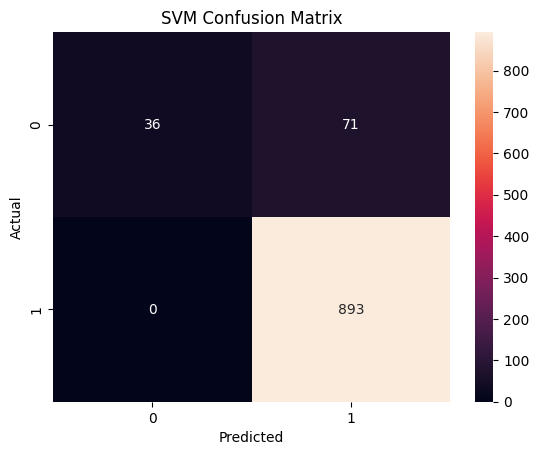

In [ ]:
# 8. SVM MODEL
# ==============================
print("\n===== SVM MODEL ====")

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


===== ISOLATION FOREST =====
Isolation Forest Accuracy: 0.184
              precision    recall  f1-score   support

           0       0.08      0.60      0.14       107
           1       0.74      0.13      0.23       893

    accuracy                           0.18      1000
   macro avg       0.41      0.37      0.18      1000
weighted avg       0.67      0.18      0.22      1000



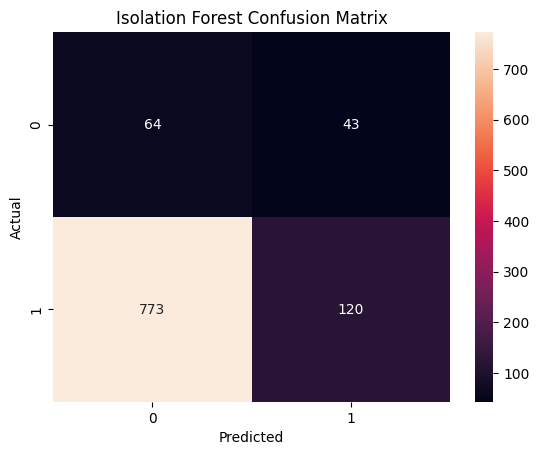

In [ ]:
# 9. ISOLATION FOREST MODEL
# ==============================
print("\n===== ISOLATION FOREST =====")

iso = IsolationForest(contamination=0.2, random_state=42)
iso.fit(X_train)

y_pred_iso = iso.predict(X_test)

# Convert output: (-1 = anomaly → 1), (1 = normal → 0)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("Isolation Forest Accuracy:", accuracy_score(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))

# Confusion Matrix
cm_iso = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d')
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

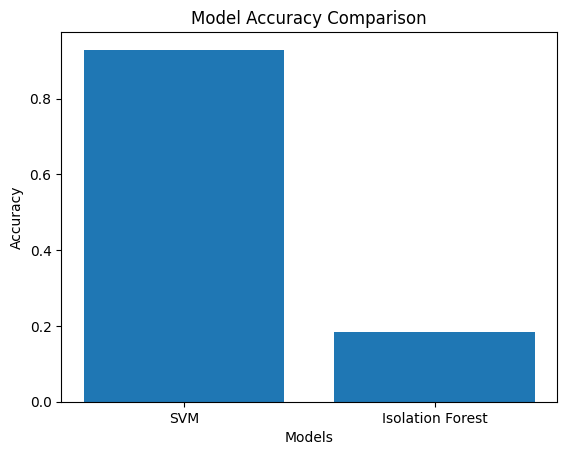

In [ ]:
svm_acc = accuracy_score(y_test, y_pred_svm)
iso_acc = accuracy_score(y_test, y_pred_iso)

models = ['SVM', 'Isolation Forest']
accuracies = [svm_acc, iso_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()